# CNG403 Assignment 2 — Personal Face Authentication

**Objective**: Fine-tune a pretrained ResNet18 to classify face images as **YOU** or **NOT YOU**, evaluate it with proper metrics, and deploy it as a Gradio web application.

**You should read, anlayse, debug and undestand the whole codebase NOT just your tasks** 

**Workflow**:
1. [Setup](#1-setup)
2. [Dataset](#2-dataset)
3. [Model](#3-model)
4. [Training](#4-training)
5. [Evaluation](#5-evaluation)
6. [Gradio App](#6-gradio-app)

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, 'src')   # make src/ importable

import json
import numpy as np
import matplotlib.pyplot as plt
import torch

print('PyTorch version :', torch.__version__)
print('Device          :', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version : 2.12.0+cpu
Device          : cpu


In [2]:
with open('config.json') as f:
    cfg = json.load(f)

print('Configuration:', json.dumps(cfg, indent=2))

# Seed is fixed — do not change
SEED = cfg['training']['seed']
print(f'\nRandom seed: {SEED}  (do not change)')

Configuration: {
  "training": {
    "batch_size": 16,
    "epochs": 20,
    "learning_rate": 0.001,
    "seed": 42,
    "patience": 7
  },
  "model": {
    "backbone": "resnet18",
    "pretrained": true,
    "num_classes": 2
  },
  "data": {
    "image_size": 224,
    "positive_dir": "data/positive",
    "negative_dir": "data/negative",
    "checkpoint_dir": "checkpoints",
    "log_dir": "logs"
  }
}

Random seed: 42  (do not change)


## 2. Dataset

The negative class is **fixed** for all students: 5 LFW identities, each contributing
4 train / 1 val / 1 test image (20 negatives per split).  
Run the cell below **once** to download and save them automatically.

### 2.1 Download negative class

In [3]:
from dataset import download_negative_class, NEGATIVE_IDENTITIES, NEGATIVE_SPLIT

print(NEGATIVE_IDENTITIES)

download_negative_class(save_dir=cfg['data']['negative_dir'])

print('\nFixed negative identities:')
for name in NEGATIVE_IDENTITIES:
    print(f'  {name}')
print(f'\nSplit indices: {NEGATIVE_SPLIT}')

['Serena Williams', 'Angelina Jolie', 'Alejandro Toledo', 'Recep Tayyip Erdogan', 'George W Bush']
Negative class already downloaded (30 images in data\negative). Skipping.

Fixed negative identities:
  Serena Williams
  Angelina Jolie
  Alejandro Toledo
  Recep Tayyip Erdogan
  George W Bush

Split indices: {'train': [0, 1, 2, 3], 'val': [4], 'test': [5]}


### 2.2 Add your positive images

Place **30 photos of your own face** into the following folders:

```
data/positive/
    train/   <-- 20 images
    val/     <-- 5  images
    test/    <-- 5  images   ⚠️  DO NOT use these in training or validation
```

Any resolution is fine — images are resized to 224×224 automatically.  
**Do not mix up the splits.** Using test images in training or validation will result in a zero grade.

### 2.3 Sanity checks

In [4]:
from pathlib import Path

pos_dir = Path(cfg['data']['positive_dir'])
neg_dir = Path(cfg['data']['negative_dir'])
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

def count_images(folder):
    folder = Path(folder)
    return sum(1 for p in folder.iterdir() if p.suffix in IMAGE_EXTS)

expected = {'train': (20, 20), 'val': (5, 5), 'test': (5, 5)}
all_ok = True

print(f"{'Split':<8} {'Positive':>10} {'Negative':>10} {'Status':>8}")
print('-' * 42)
for split, (exp_pos, exp_neg) in expected.items():
    n_pos = count_images(pos_dir / split)
    n_neg = count_images(neg_dir / split)
    ok = (n_pos == exp_pos) and (n_neg == exp_neg)
    if not ok:
        all_ok = False
    status = '✓' if ok else '✗'
    print(f'{split:<8} {n_pos:>10} {n_neg:>10} {status:>8}')

if not all_ok:
    print('\n⚠ Some counts are wrong. Check your data/positive/ folders before continuing.')
else:
    print('\nAll image counts correct.')

Split      Positive   Negative   Status
------------------------------------------
train            20         20        ✓
val               5          5        ✓
test              5          5        ✓

All image counts correct.


In [5]:
# ⚠️  DATA LEAKAGE CHECK — this check will also be run by the grader.
# If any test image appears in train/ or val/, an AssertionError is raised.
from dataset import check_no_test_leakage

check_no_test_leakage(cfg['data']['positive_dir'])

 No test-image leakage detected.


### 2.4 Visualize samples

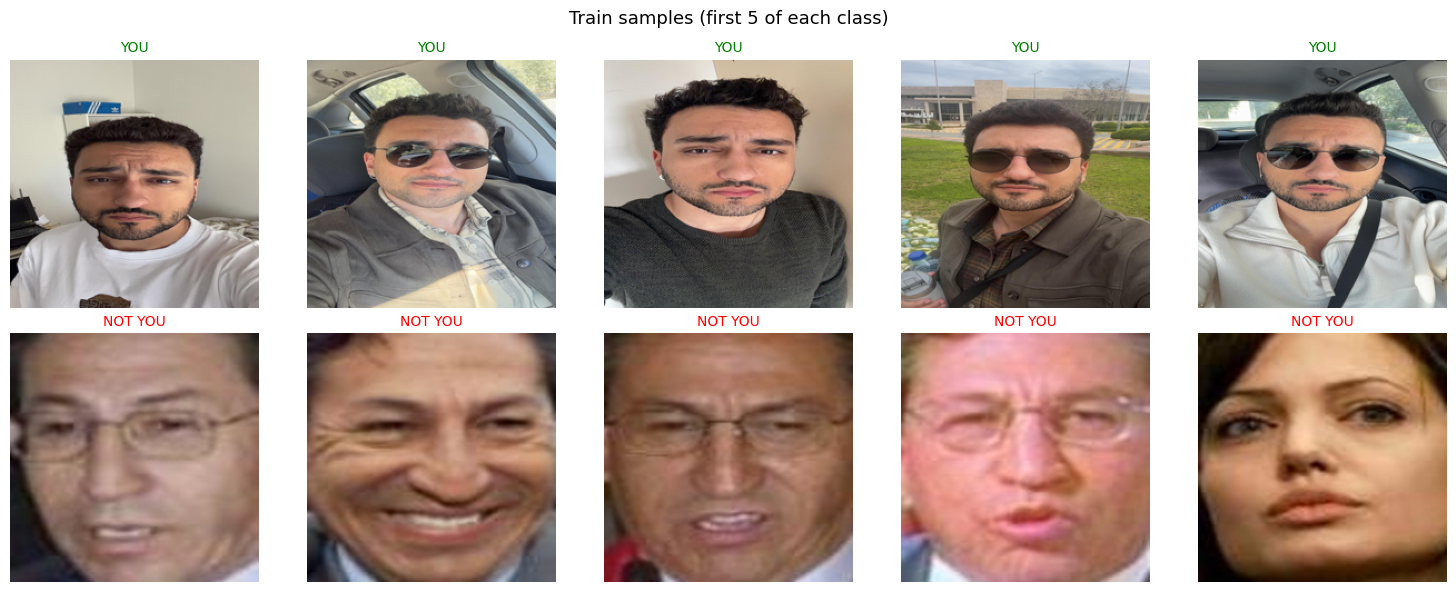

In [6]:
from PIL import Image

def show_samples(pos_folder, neg_folder, n=5, title='Train samples'):
    pos_paths = sorted(p for p in Path(pos_folder).iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png'})[:n]
    neg_paths = sorted(p for p in Path(neg_folder).iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png'})[:n]

    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    fig.suptitle(title, fontsize=13)

    for i, (ax, path) in enumerate(zip(axes[0], pos_paths)):
        ax.imshow(Image.open(path).convert('RGB').resize((224, 224)))
        ax.set_title('YOU', color='green', fontsize=10)
        ax.axis('off')

    for i, (ax, path) in enumerate(zip(axes[1], neg_paths)):
        ax.imshow(Image.open(path).convert('RGB').resize((224, 224)))
        ax.set_title('NOT YOU', color='red', fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_samples(
    pos_folder=pos_dir / 'train',
    neg_folder=neg_dir / 'train',
    title='Train samples (first 5 of each class)',
)

## 3. Model

**YOUR TASK:** Open `src/model.py` and implement `build_model()`.

Run the sanity check below after implementing.

In [7]:
# Sanity check: run src/model.py
%run src/model.py

Running model sanity checks ...

  Total parameters     : 11,177,538
  Frozen parameters    : 11,176,512
  Trainable parameters : 1,026
  Trainable param count ✓
  Output shape torch.Size([4, 2]) ✓
  model.fc is trainable ✓

All model sanity checks passed.


**Q1**: What is transfer learning, and why do we freeze the backbone?

Transfer learning means using a model that was already trained on a large dataset and adapting it to a new task. In this assignment, ResNet18 was our pretrained model, so it already learned visual features such as edges, shapes, textures, and object patterns on a large dataset.

We freeze the backbone because our dataset is very small. If we trained the whole network with only 20 personal training images, the model have risk for overfitting. Also, we could destroy the useful pretrained features. By freezing the backbone, we keep the general visual features fixed and train only the final classification layer for the YOU / NOT YOU task.

**Q2**: We have only 20 personal training images. What risks does this create?

Having only 20 personal training images creates a high risk of overfitting. The model may memorize the training photos instead of learning facial features that identify me.
Because the dataset is small, the validation and test results can also be unstable. Easy or hard images can change the accuracy a lot. We use transfer learning to reduce this risk. And we keep a separate validation and test set, and use varied images with different lighting, angles, and backgrounds.

## 4. Training

**YOUR TASK:** Open `src/train.py` and implement `train_one_epoch()`.

Run training after implementing. You should see val accuracy rise above 0.8 within a few epochs.

In [8]:
import importlib
import train as train_module
importlib.reload(train_module)

history = train_module.run('config.json')

Device: cpu
Train batches: 3  |  Val batches: 1
Epoch   1/20  train_loss=0.6101  train_acc=0.6000  val_loss=0.5992  val_acc=0.8000
  ✓ Best model saved (val_acc=0.8000)
Epoch   2/20  train_loss=0.4956  train_acc=0.8000  val_loss=0.5289  val_acc=0.8000
Epoch   3/20  train_loss=0.3265  train_acc=0.9750  val_loss=0.4809  val_acc=0.7000
Epoch   4/20  train_loss=0.2569  train_acc=0.9500  val_loss=0.4208  val_acc=0.7000
Epoch   5/20  train_loss=0.2301  train_acc=0.9750  val_loss=0.2908  val_acc=0.9000
  ✓ Best model saved (val_acc=0.9000)
Epoch   6/20  train_loss=0.1361  train_acc=1.0000  val_loss=0.2193  val_acc=1.0000
  ✓ Best model saved (val_acc=1.0000)
Epoch   7/20  train_loss=0.1588  train_acc=0.9750  val_loss=0.1697  val_acc=1.0000
Epoch   8/20  train_loss=0.1240  train_acc=1.0000  val_loss=0.1388  val_acc=1.0000
Epoch   9/20  train_loss=0.0983  train_acc=1.0000  val_loss=0.1149  val_acc=1.0000
Epoch  10/20  train_loss=0.0644  train_acc=1.0000  val_loss=0.1005  val_acc=1.0000
Epoch  1

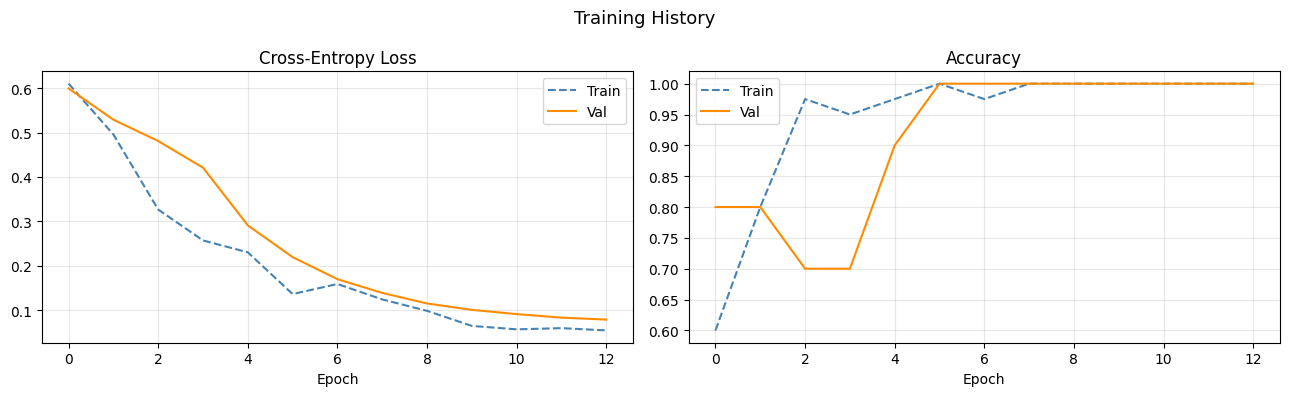

Best val accuracy : 1.0000


In [9]:
history = np.load('logs/history.npy', allow_pickle=True).item()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in zip(
    axes,
    ['loss', 'acc'],
    ['Cross-Entropy Loss', 'Accuracy'],
):
    ax.plot(history[f'train_{metric}'], '--', color='steelblue',  label='Train')
    ax.plot(history[f'val_{metric}'],   '-',  color='darkorange', label='Val')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('logs/training_curves.png', dpi=150)
plt.show()

print(f'Best val accuracy : {max(history["val_acc"]):.4f}')

## 5. Evaluation

**YOUR TASK:** Open `src/evaluate.py` and implement `compute_metrics()`.

Treat label 1 (YOU) as the positive class. Run the sanity check first, then evaluate on the test set.

In [10]:
# Sanity check: run src/evaluate.py
%run src/evaluate.py

Running compute_metrics sanity checks ...

  Perfect-prediction check ✓
  All-negative edge case ✓
  Mixed-prediction check ✓

All compute_metrics sanity checks passed.


In [11]:
import importlib
import evaluate as eval_module
importlib.reload(eval_module)

from model import build_model
from dataset import get_dataloaders

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load the best checkpoint
model = build_model(cfg['model']['backbone'], cfg['model']['num_classes'])
model.load_state_dict(torch.load('checkpoints/best_model.pt', map_location=device))
model = model.to(device)

# Get test DataLoader
_, _, test_loader = get_dataloaders(
    positive_dir=cfg['data']['positive_dir'],
    negative_dir=cfg['data']['negative_dir'],
    image_size=cfg['data']['image_size'],
    batch_size=cfg['training']['batch_size'],
)

# Run inference
probs, preds, labels = eval_module.predict_all(model, test_loader, device)
metrics = eval_module.compute_metrics(preds, labels)
eval_module.print_report(metrics, probs, labels)

Evaluation Report  (10 test images)
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000

  #    True       P(YOU)    P(NOT YOU)   Pred
  --------------------------------------------------
  1    YOU        0.9527    0.0473       YOU ✓
  2    YOU        0.9657    0.0343       YOU ✓
  3    YOU        0.8048    0.1952       YOU ✓
  4    YOU        0.7995    0.2005       YOU ✓
  5    YOU        0.9108    0.0892       YOU ✓
  6    NOT YOU    0.1938    0.8062       NOT YOU ✓
  7    NOT YOU    0.3277    0.6723       NOT YOU ✓
  8    NOT YOU    0.1510    0.8490       NOT YOU ✓
  9    NOT YOU    0.0727    0.9273       NOT YOU ✓
  10   NOT YOU    0.0402    0.9598       NOT YOU ✓


**Q3**: What does precision capture that accuracy does not? What does recall capture?

Precision measures how many of the images predicted as YOU are actually YOU. It is important because accuracy alone may hide false positives. In this task, high precision means the model does not usually incorrectly accept a NOT YOU image as YOU.
Recall measures how many of the real YOU images are correctly detected by the model. It is important because accuracy alone may hide false negatives (FN). In this task, high recall means the model does not often incorrectly reject my own face as NOT YOU.

**Q4**: What would happen to the reported test accuracy if you included test images
in the training set? Why does it invalidate the results?

If test images were included in the training set, the reported test accuracy would probably become artificially high because the model would have already seen those images during training. This would make the test set no longer independent. It invalidates the results because the purpose of the test set is to measure how well the model generalizes to unseen images. If the model trains on the test images, the evaluation becomes data leakage.

## 6. Gradio App

**YOUR TASK:** Open `src/app.py` and implement `predict()` and `build_app()`

After launching the app below:
1. Upload each of your **5 positive test images** one at a time.
2. Take a screenshot of each prediction showing both class probabilities.
3. Save them as `screenshots/screenshot_1.png` through `screenshots/screenshot_5.png`.

**Submit all 5 screenshots with your assignment.**

In [12]:
import importlib
import app as app_module
importlib.reload(app_module)

demo = app_module.build_app(config_path='config.json')
demo.launch()

Model loaded from checkpoints\best_model.pt (device: cpu)
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## 7 Submission checklist

Before submitting, verify:
- [ ] The notebook has run succesfully and all the outputs are visible.
- [ ] All questions are answered.
- [ ] `screenshots/screenshot_1.png` — test image 1, both probabilities visible
- [ ] `screenshots/screenshot_2.png` — test image 2, both probabilities visible
- [ ] `screenshots/screenshot_3.png` — test image 3, both probabilities visible
- [ ] `screenshots/screenshot_4.png` — test image 4, both probabilities visible
- [ ] `screenshots/screenshot_5.png` — test image 5, both probabilities visible
- [ ] `data/` excluded from submission zip
- [ ] `checkpoints/` excluded from submission zip
- [ ] Random seed is still 42 in `config.json`